![](img/1.png)

![](img/2.png)

![](img/3.png)

![](img/4.png)

![](img/5.png)

![](img/6.png)

![](img/7.png)

![](img/8.png)

![](img/9.png)

![](img/10.png)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("gender_classification_v7.csv")

df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [22]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["gender"] = label_encoder.fit_transform(df["gender"])
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


Text(0.5, 1.0, 'Correlation Matrix')

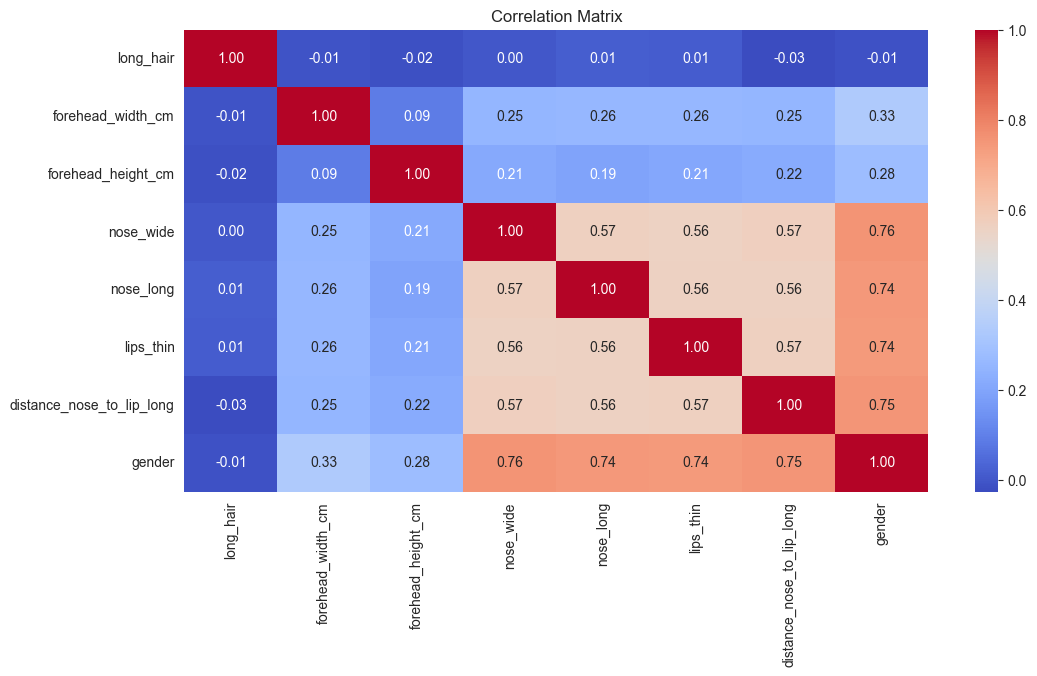

In [24]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('gender', axis=1)
y = df['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
from keras.src.optimizers import SGD
from keras.src.callbacks import EarlyStopping
from keras.src.layers import InputLayer, Dense
from keras import Sequential


def train_model(neurons, activation, learning_rate=0.1, epochs=500, batch_size=2):
    model = Sequential()

    model.add(InputLayer(shape=(X_train.shape[1],)))

    for neuron_num in neurons:
        model.add(Dense(neuron_num, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=SGD(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stopping]
    )

    return model, history

In [27]:
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_model(model, history, model_name):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{model_name} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

    y_pred = (model.predict(X_test) > 0.5).astype("int32")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()



--- MODEL 1: Simple Network with ReLU Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4998 - loss: 1.8916 - val_accuracy: 0.5005 - val_loss: 0.6910
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4958 - loss: 0.6913 - val_accuracy: 0.5504 - val_loss: 0.6845
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5470 - loss: 0.6846 - val_accuracy: 0.7762 - val_loss: 0.6826
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6531 - loss: 0.6825 - val_accuracy: 0.7003 - val_loss: 0.6790
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7144 - loss: 0.6796 - val_accuracy: 0.5684 - val_loss: 0.6754
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6340 - loss: 0.6760 - val_accuracy: 0.4995 - val_loss: 0.6793
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5637 - loss: 0.6758 - val_accuracy: 0.5075 - val_loss: 0.6697
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0

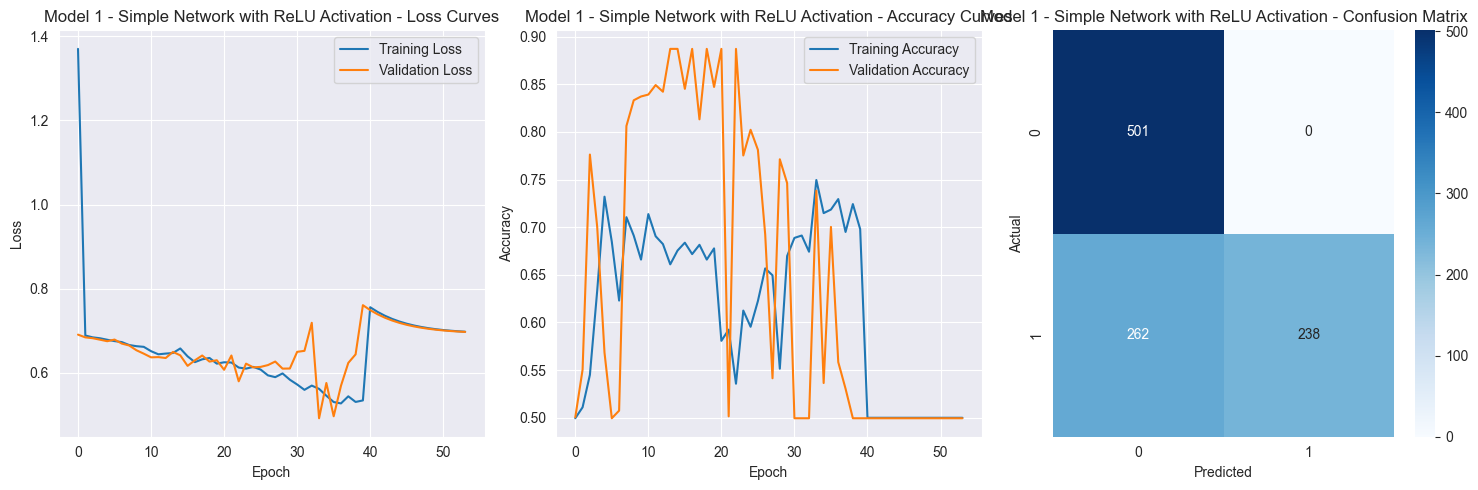

In [28]:
print("\n\n--- MODEL 1: Simple Network with ReLU Activation ---")
model1, history1 = train_model(
    neurons=[5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.1,
    activation='relu'
)
evaluate_model(model1, history1, "Model 1 - Simple Network with ReLU Activation")



--- MODEL 2: Simple Network with Sigmoid Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5067 - loss: 0.6940 - val_accuracy: 0.5005 - val_loss: 0.6914
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5086 - loss: 0.6900 - val_accuracy: 0.5005 - val_loss: 0.6891
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4993 - loss: 0.6892 - val_accuracy: 0.5005 - val_loss: 0.6876
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.6877 - val_accuracy: 0.5115 - val_loss: 0.6858
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5272 - loss: 0.6859 - val_accuracy: 0.5874 - val_loss: 0.6834
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6012 - loss: 0.6836 - val_accuracy: 0.6034 - val_loss: 0.6803
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6049 - loss: 0.6801 - val_accuracy: 0.6214 - val_loss: 0.6771
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy

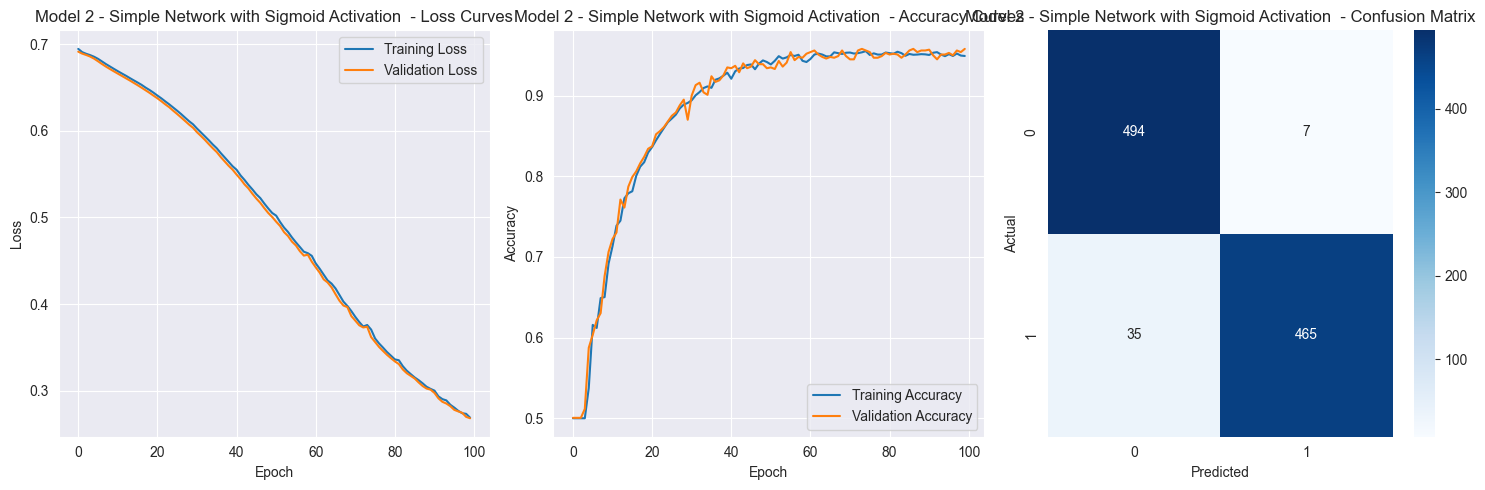

In [29]:
print("\n\n--- MODEL 2: Simple Network with Sigmoid Activation ---")
model2, history2 = train_model(
    neurons=[5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.1,
    activation='sigmoid'
)
evaluate_model(model2, history2, "Model 2 - Simple Network with Sigmoid Activation ")



--- MODEL 3: Deeper Network with ReLU Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4740 - loss: 0.7056 - val_accuracy: 0.4645 - val_loss: 0.6944
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4646 - loss: 0.6933 - val_accuracy: 0.4705 - val_loss: 0.6876
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4819 - loss: 0.6864 - val_accuracy: 0.4635 - val_loss: 0.6742
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4881 - loss: 0.6704 - val_accuracy: 0.4805 - val_loss: 0.6587
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4970 - loss: 0.6564 - val_accuracy: 0.5025 - val_loss: 0.6520
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5244 - loss: 0.6506 - val_accuracy: 0.5475 - val_loss: 0.6493
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5666 - loss: 0.6470 - val_accuracy: 0.5794 - val_loss: 0.6473
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0

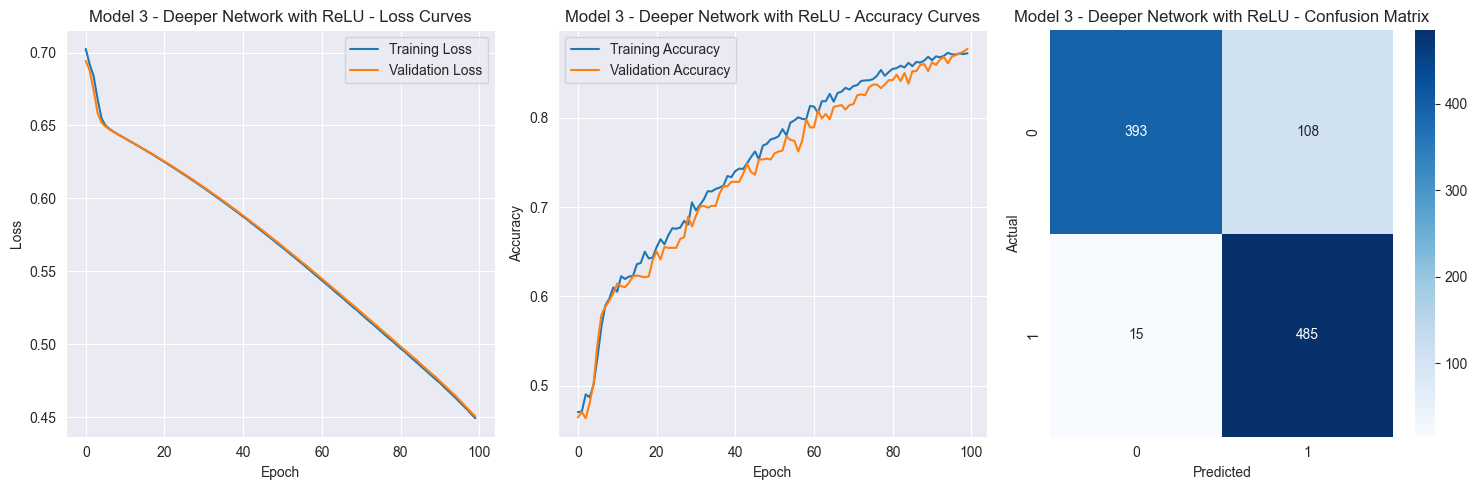

In [30]:
print("\n\n--- MODEL 3: Deeper Network with ReLU Activation ---")
model3, history3 = train_model(
    neurons=[10, 5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.01,
    activation='relu'
)
evaluate_model(model3, history3, "Model 3 - Deeper Network with ReLU")



--- MODEL 4: Wider Network with ReLU Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4880 - loss: 3.3080 - val_accuracy: 0.4995 - val_loss: 0.7135
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5437 - loss: 0.6967 - val_accuracy: 0.5654 - val_loss: 0.6682
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6911 - loss: 0.6570 - val_accuracy: 0.7542 - val_loss: 0.6328
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6835 - loss: 0.6341 - val_accuracy: 0.5005 - val_loss: 0.6274
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6941 - loss: 0.6045 - val_accuracy: 0.9231 - val_loss: 0.5777
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9221 - loss: 0.5687 - val_accuracy: 0.6933 - val_loss: 0.5649
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6122 - loss: 0.6321 - val_accuracy: 0.4995 - val_loss: 0.9690
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.

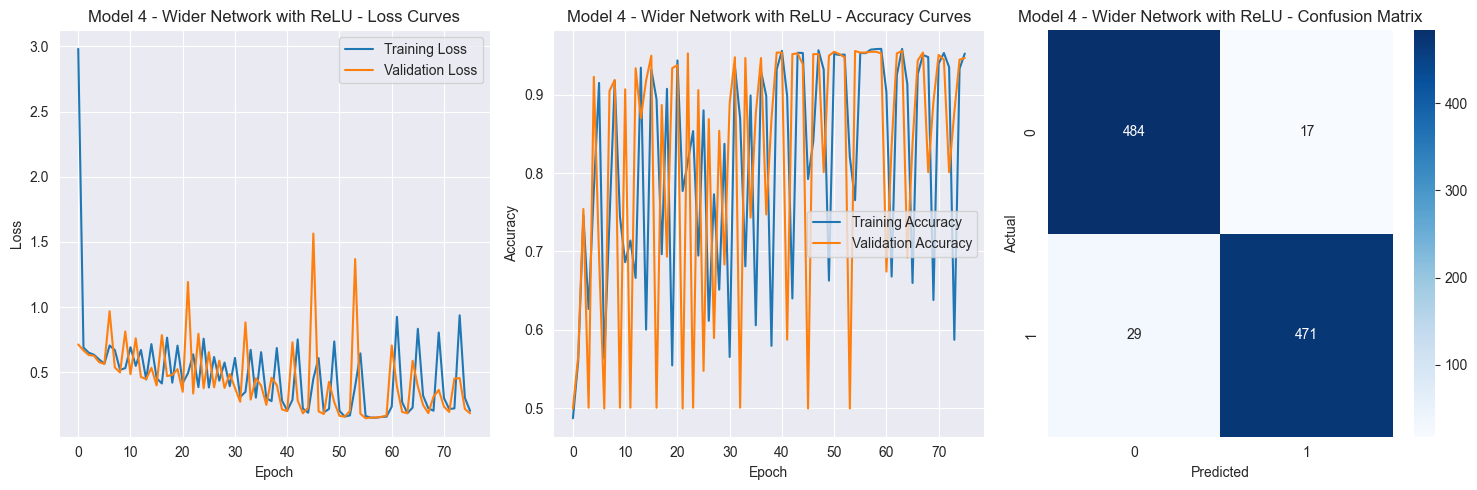

In [31]:
print("\n\n--- MODEL 4: Wider Network with ReLU Activation ---")
model4, history4 = train_model(
    neurons=[20],
    epochs=100,
    batch_size=1000,
    learning_rate=0.1,
    activation='relu'
)
evaluate_model(model4, history4, "Model 4 - Wider Network with ReLU")



--- MODEL 5: Simple Network with Tanh Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4965 - loss: 0.6943 - val_accuracy: 0.4995 - val_loss: 0.6928
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4981 - loss: 0.6931 - val_accuracy: 0.5075 - val_loss: 0.6921
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5148 - loss: 0.6919 - val_accuracy: 0.5385 - val_loss: 0.6914
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5568 - loss: 0.6911 - val_accuracy: 0.5954 - val_loss: 0.6898
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6231 - loss: 0.6888 - val_accuracy: 0.6813 - val_loss: 0.6831
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6663 - loss: 0.6769 - val_accuracy: 0.6693 - val_loss: 0.6559
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6603 - loss: 0.6502 - val_accuracy: 0.5804 - val_loss: 0.6695
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0

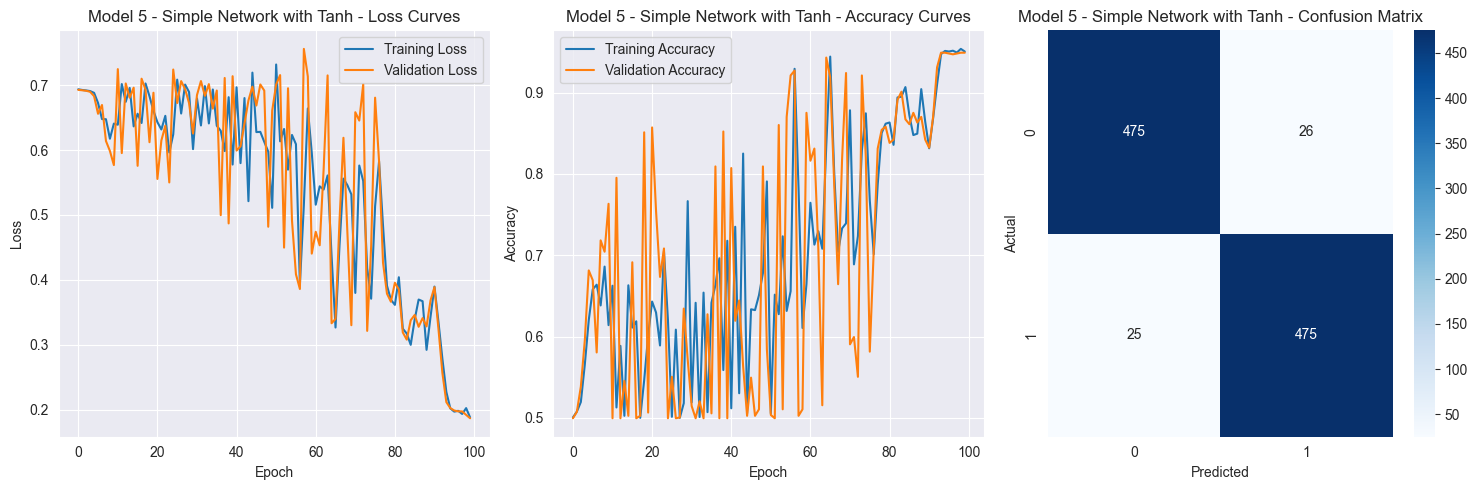

In [32]:
print("\n\n--- MODEL 5: Simple Network with Tanh Activation ---")
model5, history5 = train_model(
    neurons=[5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.1,
    activation='tanh'
)
evaluate_model(model5, history5, "Model 5 - Simple Network with Tanh")



--- MODEL 6: Deeper Network with Smaller Batch Size ---
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6570 - loss: 0.8440 - val_accuracy: 0.8831 - val_loss: 0.5711
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8919 - loss: 0.5332 - val_accuracy: 0.8991 - val_loss: 0.4097
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9445 - loss: 0.3562 - val_accuracy: 0.9211 - val_loss: 0.2647
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9483 - loss: 0.2174 - val_accuracy: 0.8252 - val_loss: 0.3723
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9450 - loss: 0.1707 - val_accuracy: 0.9530 - val_loss: 0.1391
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9483 - loss: 0.1562 - val_accuracy: 0.9520 - val_loss: 0.1212
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9529 - loss: 0.1319 - val_accuracy: 0.9481 - val_loss: 0.1125
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━

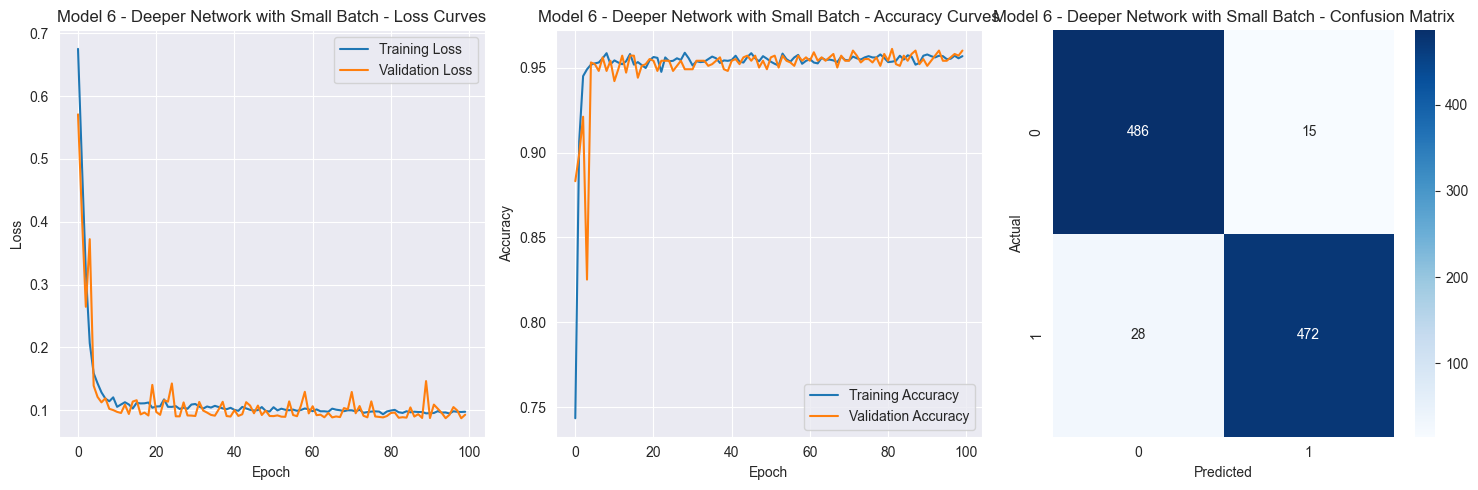

In [33]:
print("\n\n--- MODEL 6: Deeper Network with Smaller Batch Size ---")
model6, history6 = train_model(
    neurons=[10, 5],
    epochs=100,
    batch_size=32,
    learning_rate=0.01,
    activation='relu'
)
evaluate_model(model6, history6, "Model 6 - Deeper Network with Small Batch")



--- MODEL 7: Deep Network with Higher Learning Rate ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4925 - loss: 0.8200 - val_accuracy: 0.5015 - val_loss: 0.6661
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5440 - loss: 0.6617 - val_accuracy: 0.8541 - val_loss: 0.6391
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8525 - loss: 0.6304 - val_accuracy: 0.8821 - val_loss: 0.5898
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8385 - loss: 0.6203 - val_accuracy: 0.4995 - val_loss: 1.1277
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4961 - loss: 0.8958 - val_accuracy: 0.5005 - val_loss: 0.6863
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4944 - loss: 0.6848 - val_accuracy: 0.6763 - val_loss: 0.6862
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6648 - loss: 0.6745 - val_accuracy: 0.5694 - val_loss: 0.6874
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy

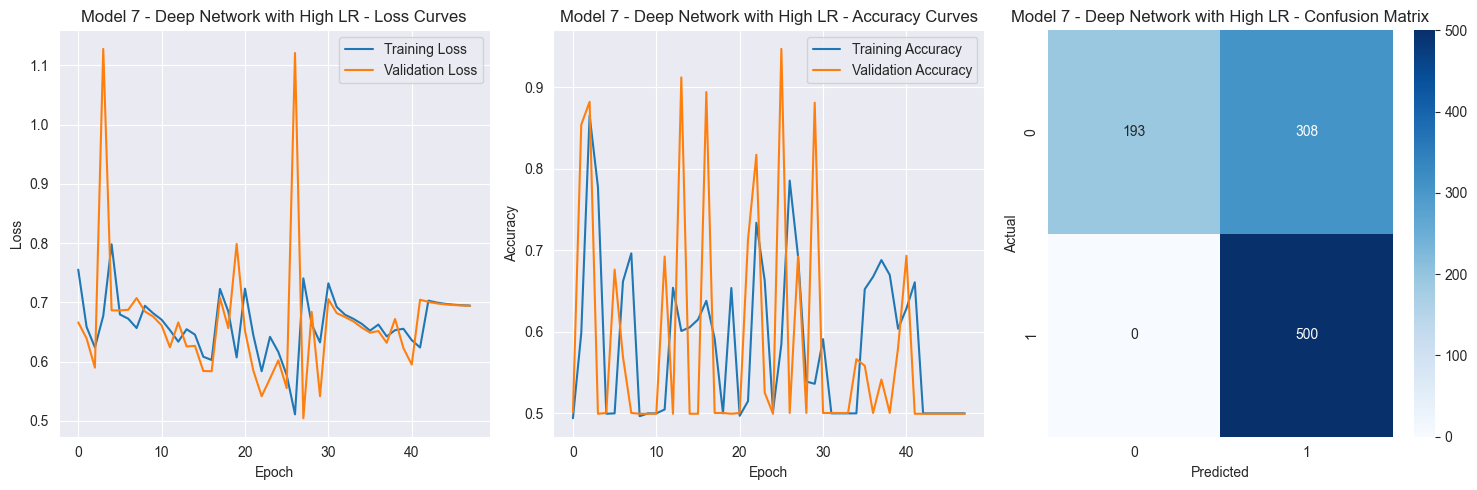

In [34]:
print("\n\n--- MODEL 7: Deep Network with Higher Learning Rate ---")
model7, history7 = train_model(
    neurons=[15, 10, 5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.2,
    activation='relu'
)
evaluate_model(model7, history7, "Model 7 - Deep Network with High LR")

In [37]:
model_names = [
    "Model 1 - Simple Network with ReLU",
    "Model 2 - Simple Network with Sigmoid",
    "Model 3 - Deeper Network with ReLU",
    "Model 4 - Wider Network with ReLU",
    "Model 5 - Simple Network with Tanh",
    "Model 6 - Deeper Network with Small Batch",
    "Model 7 - Deep Network with High LR"
]

models = [model1, model2, model3, model4, model5, model6, model7]
histories = [history1, history2, history3, history4, history5, history6, history7]

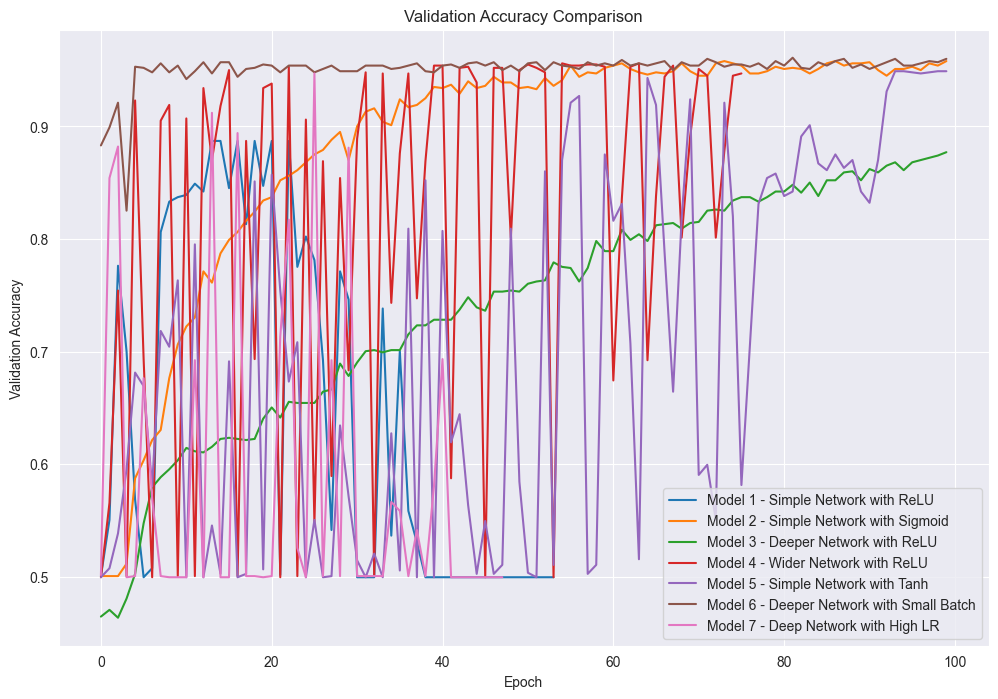

In [38]:
plt.figure(figsize=(12, 8))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=model_names[i])

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
import numpy as np

best_idx = np.argmax([model.evaluate(X_test, y_test, verbose=0)[1] for model in models])
best_model = models[best_idx]
best_model_name = model_names[best_idx]

print(f"The best performing model is: {best_model_name}")

The best performing model is: Model 2 - Simple Network with Sigmoid


In [47]:
results = []
for i, model in enumerate(models):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        'Model': model_names[i],
        'Test Accuracy': accuracy,
        'Test Loss': loss
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)
results_df

,Model,Test Accuracy,Test Loss
1,Model 2 - Simple Network with Sigmoid,0.958042,0.268139
5,Model 6 - Deeper Network with Small Batch,0.957043,0.087214
3,Model 4 - Wider Network with ReLU,0.954046,0.147875
4,Model 5 - Simple Network with Tanh,0.949051,0.186574
2,Model 3 - Deeper Network with ReLU,0.877123,0.450391
0,Model 1 - Simple Network with ReLU,0.738262,0.492403
6,Model 7 - Deep Network with High LR,0.692308,0.504277
